In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input ,Embedding, SimpleRNN, LSTM, Dense , Bidirectional , Dropout


In [2]:
fake = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fake (1).xls')
true = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/True (1).xls')

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
fake["subject"].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
true["subject"].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


In [7]:
fake["category"]=1
true["category"]=0

In [8]:
fake.head()

,title,text,subject,date,category
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [9]:
true.head()

,title,text,subject,date,category
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [10]:
df= pd.concat((fake , true)).reset_index(drop=True)

In [11]:
df

,title,text,subject,date,category
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


In [12]:
df.category.value_counts()

,count
category,
1,23481
0,21417


/tmp/ipykernel_1731/1277603589.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


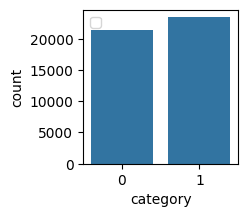

In [13]:
plt.figure(figsize=(2,2))
sns.countplot(x="category" , data= df)
plt.legend()

In [14]:
df = df[['text' , 'category']]
df

,text,category
0,Donald Trump just couldn t wish all Americans ...,1
1,House Intelligence Committee Chairman Devin Nu...,1
2,"On Friday, it was revealed that former Milwauk...",1
3,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis used his annual Christmas Day mes...,1
...,...,...
44893,BRUSSELS (Reuters) - NATO allies on Tuesday we...,0
44894,"LONDON (Reuters) - LexisNexis, a provider of l...",0
44895,MINSK (Reuters) - In the shadow of disused Sov...,0
44896,MOSCOW (Reuters) - Vatican Secretary of State ...,0


In [15]:
df.isna().sum()

,0
text,0
category,0


In [16]:


blanks = []

for index , text in df['text'].items():
  if text.isspace():
    blanks.append(index)
len(blanks)

631

In [17]:
blanks

[10923,
 11041,
 11190,
 11225,
 11236,
 11241,
 11247,
 11249,
 11267,
 11268,
 11283,
 11284,
 11285,
 11289,
 11290,
 11292,
 11295,
 11296,
 11301,
 11303,
 11304,
 11305,
 11309,
 11314,
 11317,
 11319,
 11322,
 11330,
 11334,
 11335,
 11340,
 11343,
 11348,
 11351,
 11352,
 11357,
 11371,
 11373,
 11374,
 11382,
 11397,
 11402,
 11403,
 11409,
 11410,
 11412,
 11415,
 11419,
 11421,
 11427,
 11431,
 11432,
 11440,
 11448,
 11450,
 11453,
 11462,
 11464,
 11465,
 11472,
 11473,
 11475,
 11478,
 11489,
 11491,
 11493,
 11494,
 11501,
 11505,
 11507,
 11520,
 11531,
 11532,
 11533,
 11538,
 11542,
 11547,
 11549,
 11551,
 11559,
 11563,
 11581,
 11585,
 11589,
 11590,
 11614,
 11624,
 11625,
 11627,
 11631,
 11636,
 11637,
 11643,
 11650,
 11658,
 11661,
 11672,
 11679,
 11681,
 11684,
 11686,
 11688,
 11692,
 11708,
 11718,
 11729,
 11739,
 11753,
 11765,
 11768,
 11777,
 11782,
 11786,
 11788,
 11792,
 11793,
 11803,
 11806,
 11813,
 11821,
 11831,
 11832,
 11841,
 11844,
 11848,


In [18]:
df['text'][10923]

' '

In [19]:
df.shape

(44898, 2)

In [20]:
df.drop(blanks , inplace=True)

/tmp/ipykernel_1731/449871517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(blanks , inplace=True)


In [21]:
df.shape

(44267, 2)

In [25]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import re

lemma = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [26]:


#text cleaning function
def clean_text(text):



    string = ""

    #lower casing
    text=text.lower()

    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"'ll"," will",text)
    text=re.sub(r"'ve"," have",text)
    text=re.sub(r"'re"," are",text)
    text=re.sub(r"'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)

    #removing any special character
    text=re.sub(r"[-()""#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)
    text=re.sub('[^A-Za-z0-9]+',' ', text)

    for word in text.split():
        if word not in stop_words:
            string+=lemma.lemmatize(word)+" "

    return string

In [27]:
df['text'] = df['text'].apply(clean_text)

/tmp/ipykernel_1731/1163271480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].apply(clean_text)


In [28]:
df['text'][10]

'centerpiece donald trump campaign presidency white supremacist way many public feud get involve people color one favorite target course player national football league dare exercise first amendment right kneeling national anthem protest racist police brutality well one person figured racism bad business even get orange overlord elected founder pizza chain papa john man never right side history number issue plus pizza suck decided complain player protesting sale really dropped turn racism pay know corporation bottom line therefore papa john schnatter longer ceo hack pizza chain breaking papa john founder john schnatter step ceo announcement come week criticized nfl protest ap business news apbusiness december 21 2017the thing people certainly allowed political opinion realize opinion often come dire consequence especially one business trying garner sale support people one would presume goal ceo one know whether pressure shareholder public outcry boycott even nfl anything stepping right

word cloud

In [29]:
from wordcloud import WordCloud

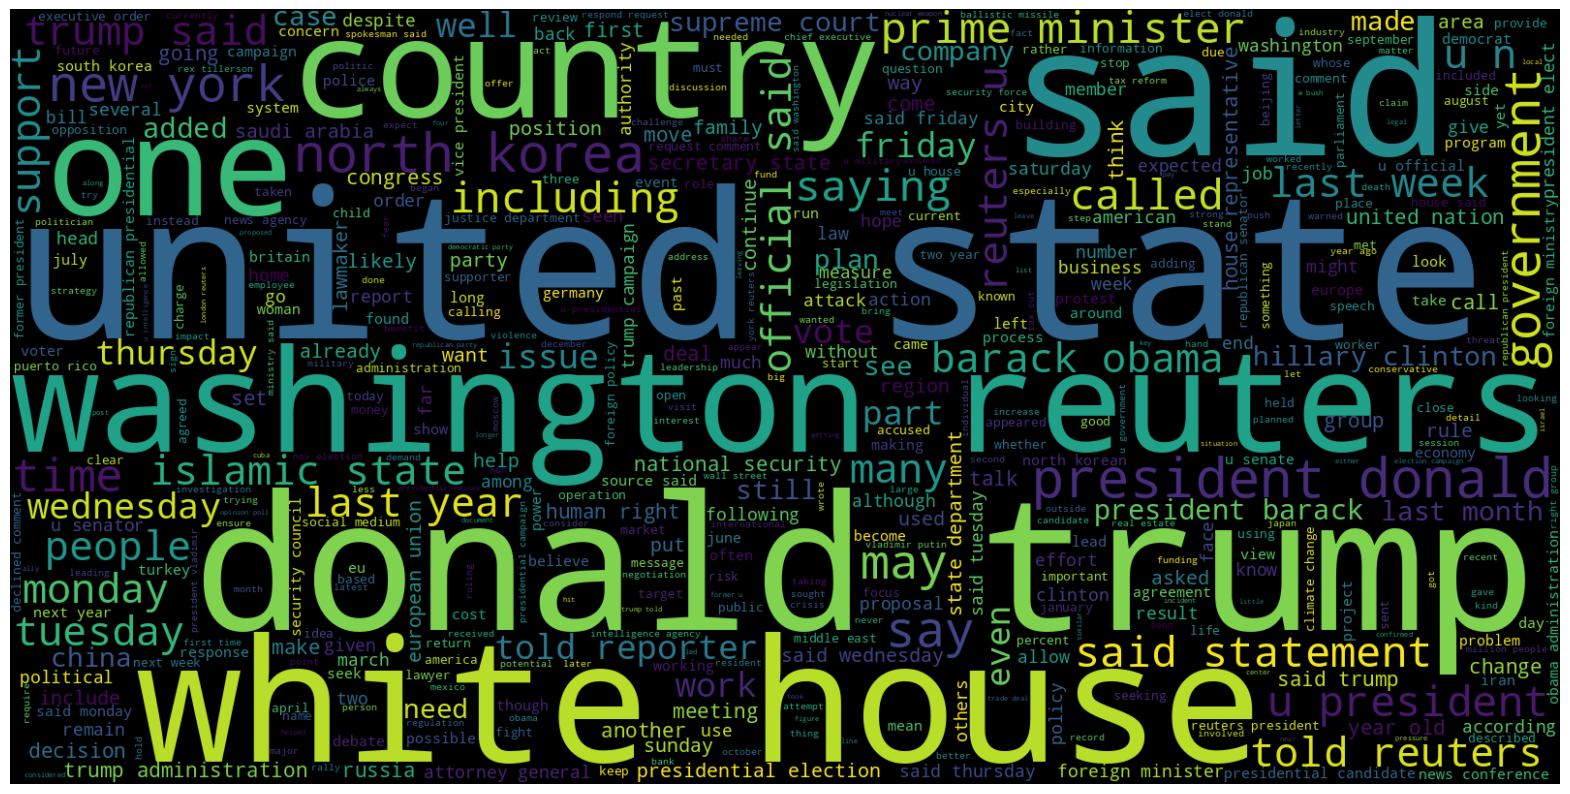

In [30]:
plt.figure(figsize=(20,20))
WC = WordCloud(max_words = 500 , width=1600 , height = 800).generate(" ".join(df[df.category==0].text))
plt.axis('off')
plt.imshow(WC , interpolation='bilinear')
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

x = np.array(df['text'])
y= np.array(df['category'])



In [32]:
vocab_size = 10000
max_length = 200


tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(x)

x = tokenizer.texts_to_sequences(x)

In [33]:
x = pad_sequences(x, maxlen=max_length, padding='post', truncating='post')

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

RNN

In [36]:
model_rnn = Sequential([

    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),
    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9482 - loss: 0.1237 - val_accuracy: 0.9976 - val_loss: 0.0144
Epoch 2/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9966 - loss: 0.0165 - val_accuracy: 0.9972 - val_loss: 0.0163
Epoch 3/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9971 - loss: 0.0141 - val_accuracy: 0.9980 - val_loss: 0.0110
Epoch 4/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9457 - loss: 0.1500 - val_accuracy: 0.9872 - val_loss: 0.0523
Epoch 5/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.9827 - loss: 0.0587 - val_accuracy: 0.9826 - val_loss: 0.0649
Epoch 6/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9925 - loss: 0.0250 - val_accuracy: 0.9920 - val_loss: 0.0359
Epoch 7/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.9964 - loss: 0.0133 - val_accuracy: 0.9911 - val_loss: 0.0370
Epoch 8/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.9938 - loss: 0.0197 - 

In [38]:
predictions = model_rnn.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print(classification_report(y_test,predictions))

277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      4269
           1       0.95      0.93      0.94      4585

    accuracy                           0.94      8854
   macro avg       0.94      0.94      0.94      8854
weighted avg       0.94      0.94      0.94      8854



BI DIRECTINAL RNN

In [39]:
bi_rnn_model = Sequential([

    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    Bidirectional(SimpleRNN(64)),

    Dense(1, activation='sigmoid')
])

bi_rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bi_rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,833 (4.98 MB)

 Trainable params: 1,304,833 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history_bi = bi_rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accuracy: 0.9987 - val_loss: 0.0057
Epoch 2/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 130s 79ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9989 - val_loss: 0.0058
Epoch 3/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 83s 81ms/step - accuracy: 0.9998 - loss: 8.4043e-04 - val_accuracy: 0.9990 - val_loss: 0.0071
Epoch 4/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 72s 81ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9990 - val_loss: 0.0059
Epoch 5/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 89s 89ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9987 - val_loss: 0.0071
Epoch 6/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.9999 - loss: 8.5660e-04 - val_accuracy: 0.9982 - val_loss: 0.0071
Epoch 7/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 76s 84ms/step - accuracy: 0.9998 - loss: 7.1458e-04 - val_accuracy: 0.9992 - val_loss: 0.0066
Epoch 8/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 78s 80ms/step - accuracy: 0.9997 - lo

In [42]:
predictions = bi_rnn_model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print(classification_report(y_test,predictions))

277/277 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4269
           1       1.00      1.00      1.00      4585

    accuracy                           1.00      8854
   macro avg       1.00      1.00      1.00      8854
weighted avg       1.00      1.00      1.00      8854



DEEP RNN

In [44]:
deep_rnn_model = Sequential([

    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    SimpleRNN(128, return_sequences=True),

    SimpleRNN(64),

   # Dropout(0.3),

    Dense(1, activation='sigmoid')
])

deep_rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deep_rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,325,313 (5.06 MB)

 Trainable params: 1,325,313 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history_DEEP = bi_rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 75s 85ms/step - accuracy: 0.9999 - loss: 2.9724e-04 - val_accuracy: 0.9989 - val_loss: 0.0102
Epoch 2/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 1.0000 - loss: 2.9606e-05 - val_accuracy: 0.9989 - val_loss: 0.0104
Epoch 3/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 89s 93ms/step - accuracy: 1.0000 - loss: 9.8633e-06 - val_accuracy: 0.9987 - val_loss: 0.0106
Epoch 4/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 78s 88ms/step - accuracy: 1.0000 - loss: 6.8636e-06 - val_accuracy: 0.9986 - val_loss: 0.0114
Epoch 5/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 1.0000 - loss: 4.5085e-06 - val_accuracy: 0.9986 - val_loss: 0.0127
Epoch 6/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 75s 85ms/step - accuracy: 1.0000 - loss: 2.5841e-06 - val_accuracy: 0.9986 - val_loss: 0.0132
Epoch 7/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 72s 81ms/step - accuracy: 1.0000 - loss: 1.9490e-06 - val_accuracy: 0.9986 - val_loss: 0.0124
Epoch 8/10
886/886 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accura

In [46]:
predictions = bi_rnn_model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print(classification_report(y_test,predictions))

277/277 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4269
           1       1.00      1.00      1.00      4585

    accuracy                           1.00      8854
   macro avg       1.00      1.00      1.00      8854
weighted avg       1.00      1.00      1.00      8854



In [47]:

sample_news = """
Government gives free laptops
to every citizen tomorrow
"""

# Clean text
sample_news = clean_text(sample_news)

# Convert to sequence
sample_seq = tokenizer.texts_to_sequences(
    [sample_news]
)

In [49]:
sample_seq = pad_sequences(sample_seq, maxlen=max_length, padding='post', truncating='post')

models = [model_rnn , bi_rnn_model , deep_rnn_model]

for mode in models:
    result = mode.predict(sample_seq)

    # Output
    if result > 0.5:
        print("FAKE NEWS")
    else:
        print("REAL NEWS")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
REAL NEWS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
REAL NEWS
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
REAL NEWS
